# Correlation Analysis

Two datasets are explored:
- **Part 1: Tips** — simple Pearson & Spearman example
- **Part 2: California Housing** — real-world data prep (outliers, log transform)
- **Part 3: Anscombe's Quartet** — why visualization always comes first

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

---
## Part 1: Tips — Pearson & Spearman Correlation

## 1. Dataset Overview

In [2]:
tips = sns.load_dataset('tips')
print(f'Shape: {tips.shape}')
tips.head()

Shape: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 2. Visual Exploration

Before computing any correlation coefficient, always look at the scatterplot — outliers and non-linearity are invisible in a single number.

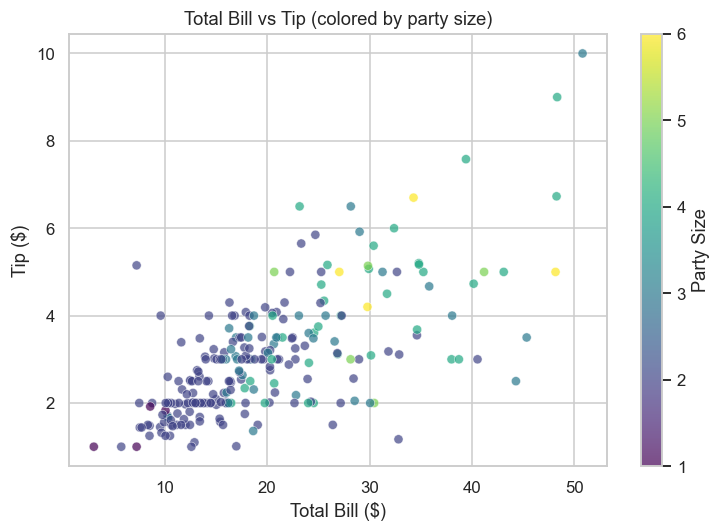

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    tips['total_bill'], tips['tip'],
    c=tips['size'], cmap='viridis', alpha=0.7, edgecolors='white', linewidths=0.4
)
fig.colorbar(scatter, ax=ax, label='Party Size')
ax.set_xlabel('Total Bill ($)')
ax.set_ylabel('Tip ($)')
ax.set_title('Total Bill vs Tip (colored by party size)')
plt.tight_layout()
plt.show()

## 3. Pearson Correlation

### Why not just use covariance?

**Covariance** captures how two variables move together:

$$\text{Cov}(x, y) = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{n - 1}$$

The problem: covariance is **scale-dependent**. If you measure income in dollars vs. thousands of dollars, you get completely different numbers — making it impossible to compare across datasets or variable pairs.

| Cov(x, y) | What it tells you |
|-----------|-------------------|
| > 0 | x and y tend to increase together |
| < 0 | one increases as the other decreases |
| = 0 | no linear co-movement |
| magnitude | **uninterpretable** — depends on units |

### Pearson $r$ = normalized covariance

Pearson correlation divides covariance by the product of standard deviations, removing the effect of scale:

$$r = \frac{\text{Cov}(x, y)}{s_x \cdot s_y} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$

This constrains $r$ to $[-1, 1]$, making it **unitless and directly comparable**:

| $r$ | Interpretation |
|-----|----------------|
| $\pm 1$ | perfect linear relationship |
| $\pm 0.7$–$1$ | strong |
| $\pm 0.4$–$0.7$ | moderate |
| $\pm 0$–$0.4$ | weak or none |

**Hypotheses:** $H_0: r = 0$ (no linear correlation), $\alpha = 0.05$

**When to use:** both variables are approximately normal, relationship is linear, no severe outliers.

In [4]:
r, p = stats.pearsonr(tips['total_bill'], tips['tip'])
print(f'Pearson r  = {r:.4f}')
print(f'p-value    = {p:.2e}')
print(f'=> {"Significant" if p < 0.05 else "Not significant"} linear correlation (α = 0.05)')

Pearson r  = 0.6757
p-value    = 6.69e-34
=> Significant linear correlation (α = 0.05)


## 4. Spearman Correlation

**Definition:** measures the strength of the *monotonic* relationship using ranks — does not assume linearity or normality.

$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$

**When to use:** ordinal data, non-linear but monotonic relationships, or when Pearson assumptions are violated.

In [5]:
rho, p_sp = stats.spearmanr(tips['total_bill'], tips['tip'])
print(f'Spearman ρ = {rho:.4f}')
print(f'p-value    = {p_sp:.2e}')
print(f'=> {"Significant" if p_sp < 0.05 else "Not significant"} monotonic correlation (α = 0.05)')

Spearman ρ = 0.6790
p-value    = 2.50e-34
=> Significant monotonic correlation (α = 0.05)


**Part 1 Summary:**

| Metric | Value | p-value |
|--------|-------|---------|
| Pearson $r$ | 0.676 | 6.7e-34 |
| Spearman $\rho$ | 0.679 | 2.5e-34 |

- Both tests confirm a **moderate positive correlation** between total bill and tip
- Pearson ≈ Spearman → the relationship is approximately linear
- $p \approx 0$ → the correlation is highly statistically significant

---
## Part 2: California Housing — Data Preparation Before Correlation

## 5. Dataset Overview

In [6]:
data = fetch_california_housing(as_frame=True).frame
print(f'Shape: {data.shape}')
data.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 6. Visual Exploration (Raw Data)

In real data, correlation is **never applied blindly** — data needs preparation first.

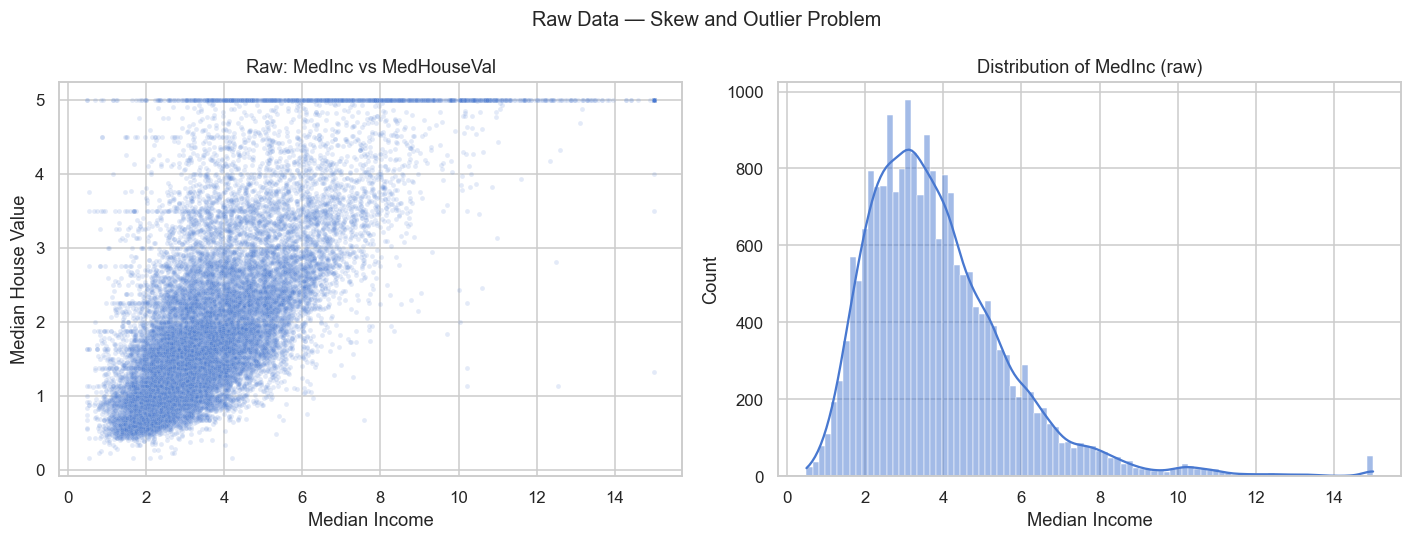

Note: horizontal band at MedHouseVal ≈ 5 suggests a cap — values are censored at the top.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x='MedInc', y='MedHouseVal', data=data, ax=axes[0], alpha=0.15, s=10)
axes[0].set_title('Raw: MedInc vs MedHouseVal')
axes[0].set_xlabel('Median Income')
axes[0].set_ylabel('Median House Value')

sns.histplot(data['MedInc'], ax=axes[1], kde=True)
axes[1].set_title('Distribution of MedInc (raw)')
axes[1].set_xlabel('Median Income')

plt.suptitle('Raw Data — Skew and Outlier Problem', fontsize=13)
plt.tight_layout()
plt.show()

print('Note: horizontal band at MedHouseVal ≈ 5 suggests a cap — values are censored at the top.')

## 7. Data Preparation

Steps:
1. **Filter outliers** — remove rows where `MedInc ≥ 12` (extreme right tail)
2. **Log-transform** both `MedInc` and `MedHouseVal` to reduce skewness

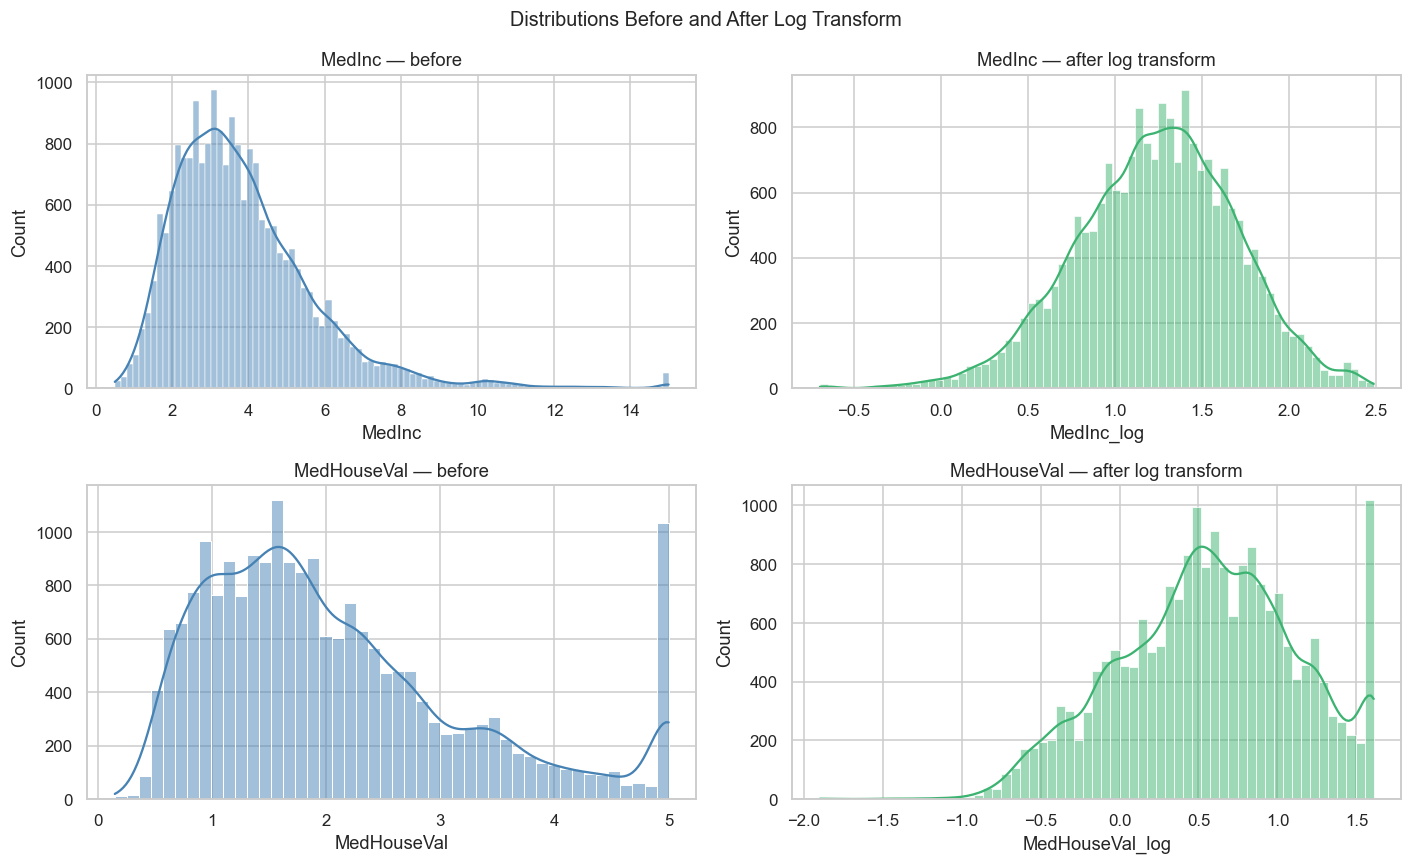

In [10]:
data_clean = data.query('MedInc < 12').copy()
data_clean['MedInc_log'] = np.log(data_clean['MedInc'])
data_clean['MedHouseVal_log'] = np.log(data_clean['MedHouseVal'])

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(data['MedInc'], ax=axes[0, 0], kde=True, color='steelblue')
axes[0, 0].set_title('MedInc — before')

sns.histplot(data_clean['MedInc_log'], ax=axes[0, 1], kde=True, color='mediumseagreen')
axes[0, 1].set_title('MedInc — after log transform')

sns.histplot(data['MedHouseVal'], ax=axes[1, 0], kde=True, color='steelblue')
axes[1, 0].set_title('MedHouseVal — before')

sns.histplot(data_clean['MedHouseVal_log'], ax=axes[1, 1], kde=True, color='mediumseagreen')
axes[1, 1].set_title('MedHouseVal — after log transform')

plt.suptitle('Distributions Before and After Log Transform', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Correlation on Transformed Data

In [11]:
r_log, p_log = stats.pearsonr(data_clean['MedInc_log'], data_clean['MedHouseVal_log'])
rho_log, p_rho_log = stats.spearmanr(data_clean['MedInc_log'], data_clean['MedHouseVal_log'])
rho_raw, p_rho_raw = stats.spearmanr(data_clean['MedInc'], data_clean['MedHouseVal'])

print('Correlation on log-transformed data:')
print(f'  Pearson r   = {r_log:.4f}  (p = {p_log:.2e})')
print(f'  Spearman ρ  = {rho_log:.4f}  (p = {p_rho_log:.2e})')
print()
print('Spearman on raw data (rank-robustness check):')
print(f'  Spearman ρ  = {rho_raw:.4f}  (p = {p_rho_raw:.2e})')
print()
print('Note: Spearman on raw ≈ Spearman on log — ranks are invariant to monotonic transforms.')

Correlation on log-transformed data:
  Pearson r   = 0.6670  (p = 0.00e+00)
  Spearman ρ  = 0.6720  (p = 0.00e+00)

Spearman on raw data (rank-robustness check):
  Spearman ρ  = 0.6720  (p = 0.00e+00)

Note: Spearman on raw ≈ Spearman on log — ranks are invariant to monotonic transforms.


## 9. Correlation Matrix

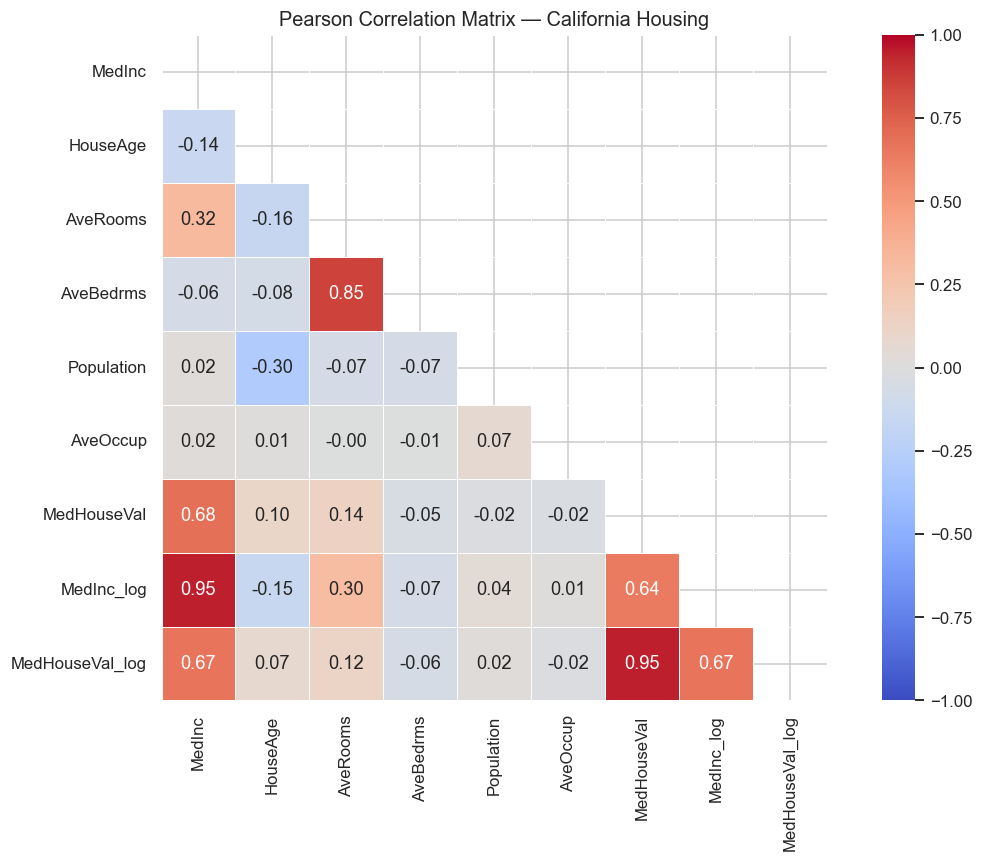

In [13]:
# Add log transforms for all skewed columns
data_clean['AveRooms_log'] = np.log(data_clean['AveRooms'].clip(lower=0.01))
data_clean['HouseAge_log'] = np.log(data_clean['HouseAge'].clip(lower=0.01))

cols = [
    'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population',
    'AveOccup', 'MedHouseVal', 'MedInc_log', 'MedHouseVal_log'
]
corr_matrix = data_clean[cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, mask=mask, ax=ax,
    linewidths=0.5, square=True
)
ax.set_title('Pearson Correlation Matrix — California Housing', fontsize=13)
plt.tight_layout()
plt.show()

**Part 2 Summary:**

- Raw scatter shows severe skew and a censored ceiling — applying Pearson directly would give misleading results
- After outlier filtering and log transform: Pearson $r \approx 0.67$, Spearman $\rho \approx 0.68$
- **Key insight:** Spearman on raw data equals Spearman on log-transformed data — because ranks are invariant to monotonic transforms
- **Rule:** always inspect distributions → remove outliers → transform if skewed → then correlate

---
## Part 3: Anscombe's Quartet — Visualization Before Correlation

Anscombe's Quartet (1973) consists of **four datasets with nearly identical summary statistics**:

| Statistic | Value (all 4 datasets) |
|-----------|------------------------|
| mean(x) | ≈ 9.0 |
| mean(y) | ≈ 7.5 |
| std(x) | ≈ 3.32 |
| std(y) | ≈ 2.03 |
| Pearson $r$ | ≈ 0.816 |
| Regression line | $\hat{y} = 3 + 0.5x$ |

Yet their distributions are **radically different**.

> **Lesson: always visualize before computing correlation.**

## 10. Load Data

In [17]:
anscombe = sns.load_dataset('anscombe')
print('Datasets:', anscombe['dataset'].unique())
anscombe.head(8)

Datasets: <StringArray>
['I', 'II', 'III', 'IV']
Length: 4, dtype: str


,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33
5,I,14.0,9.96
6,I,6.0,7.24
7,I,4.0,4.26


## 11. Summary Statistics (same for all four)

In [18]:
rows = []
for name, group in anscombe.groupby('dataset'):
    r_val, _ = stats.pearsonr(group['x'], group['y'])
    rows.append({
        'Dataset': name,
        'mean(x)': round(group['x'].mean(), 2),
        'mean(y)': round(group['y'].mean(), 2),
        'std(x)':  round(group['x'].std(), 2),
        'std(y)':  round(group['y'].std(), 2),
        'Pearson r': round(r_val, 3),
    })

pd.DataFrame(rows).set_index('Dataset')

,mean(x),mean(y),std(x),std(y),Pearson r
Dataset,,,,,
I,9.0,7.5,3.32,2.03,0.816
II,9.0,7.5,3.32,2.03,0.816
III,9.0,7.5,3.32,2.03,0.816
IV,9.0,7.5,3.32,2.03,0.817


## 12. Visualize All Four Datasets

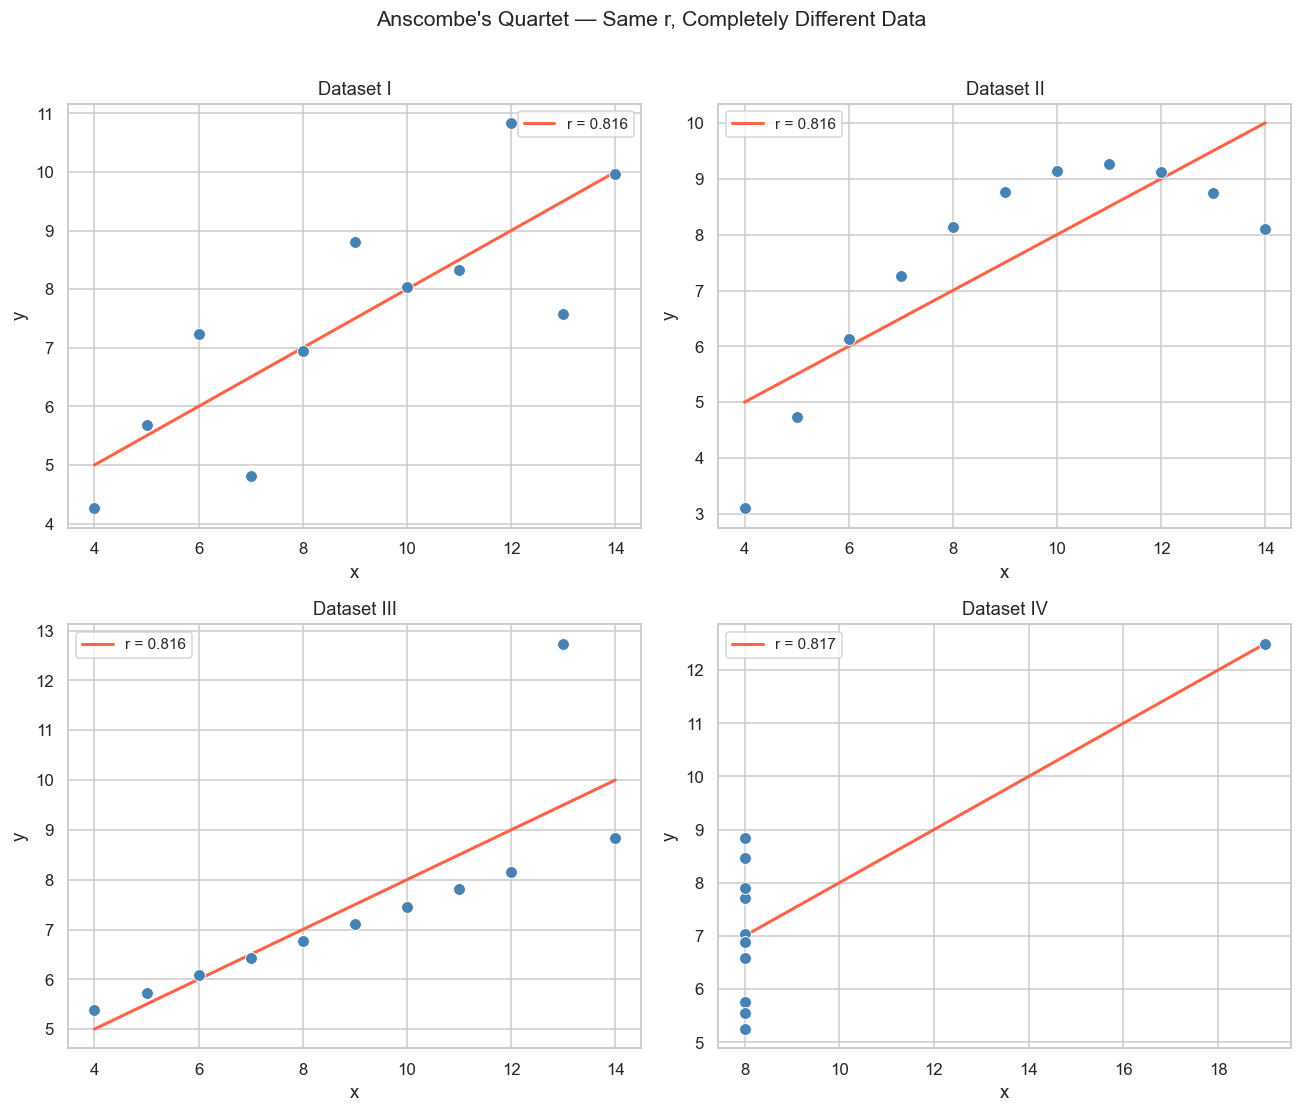

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, group) in zip(axes.flat, anscombe.groupby('dataset')):
    # scatter
    ax.scatter(group['x'], group['y'], color='steelblue', s=60, edgecolors='white', linewidths=0.6, zorder=3)

    # regression line
    slope, intercept, r_val, *_ = stats.linregress(group['x'], group['y'])
    x_range = np.linspace(group['x'].min(), group['x'].max(), 100)
    ax.plot(x_range, intercept + slope * x_range, color='tomato', linewidth=2, label=f'r = {r_val:.3f}')

    ax.set_title(f'Dataset {name}', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=10)

plt.suptitle("Anscombe's Quartet — Same r, Completely Different Data", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Takeaway:**

| Dataset | What's really going on |
|---------|------------------------|
| **I** | Normal linear relationship — Pearson is appropriate |
| **II** | Curved (quadratic) relationship — Pearson misleads |
| **III** | Linear but one extreme outlier skews the result |
| **IV** | Vertical cluster + single leverage point — $r$ is meaningless |

All four datasets produce $r \approx 0.816$ and the same regression line $\hat{y} = 3 + 0.5x$.

> **Rule: visualize → check assumptions → compute correlation**
>
> Correlation $\neq$ full picture. The same $r$ can describe completely different data structures.